In [1]:
import json
import numpy as np
from PIL import Image
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

from dataset_parameters import *

In [2]:
datas, classes = [], []

with open("dataset/labels/labels.json", "r") as lab_file:
    file = json.load(lab_file)
    labels = list(zip(file.keys(), file.values()))

    import_loop = tqdm(labels, total = len(labels), leave = True)

    for lab in import_loop:
        img = Image.open(DATASET_IMAGES_PATH + lab[0])
        datas.append(np.array(img))
        classes.append(lab[1]["class"])

print(f"Dataset size: {len(datas)}")

# SHUFFLE THE ELEMENTS BUT KEEP THE CORRESPONDENCES
shuffled = list(zip(datas, classes))

random.shuffle(shuffled)

datas_shuffle, classes_shuffle = zip(*shuffled)

# CONVERT THE RESULT TO LISTS
datas = list(datas_shuffle)
classes = list(classes_shuffle)

100%|██████████| 19993/19993 [04:20<00:00, 76.80it/s] 

Dataset size: 19993


In [3]:
# TRAIN/TEST DATASET SPLIT
ds_size = len(datas)
split = int((ds_size / 100) * 70)

datas_train, classes_train = datas[:split], classes[:split]
datas_test, classes_test = datas[split:], classes[split:]

print(f"Train set size: {len(datas_train)}, Test set size: {len(datas_test)}")
print(f"Images dimensions: {np.size(datas_train[0])}")

Train set size: 13995, Test set size: 5998
Images dimensions: 4946112


### Siren Detection Network

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import confusion_matrix

from custom_datasets import SirenDetectionDataset

In [5]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
MODEL_PATH = 'models/siren_detection.pth'
BS_TRAIN, BS_TEST = 32, 1
LR = 0.001
EPOCHS = 20

In [6]:
# DATASETS
train_dataset = SirenDetectionDataset(datas_train, classes_train)
test_dataset = SirenDetectionDataset(datas_test, classes_test)

# DATALOADERS
train_dataloader = DataLoader(train_dataset, batch_size = BS_TRAIN, shuffle = True)
test_dataloader = DataLoader(test_dataset, batch_size = BS_TEST, shuffle = True)

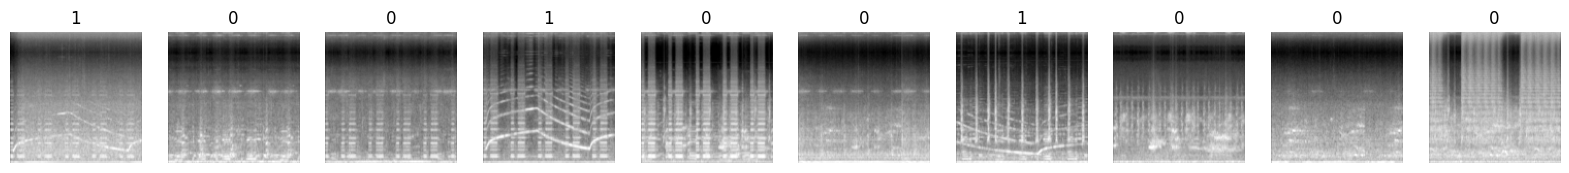

In [7]:
to_pil = transforms.ToPILImage()
figure = plt.figure(figsize=(20,20))
cols, rows = 10, 1

for i in range(1, rows + 1):
    for j in range(0, cols):
        image = test_dataset[i+j][0]
        label = test_dataset[i+j][1]
        figure.add_subplot(rows, cols, i + j)
        plt.axis("off")
        plt.title(label)
        plt.imshow(to_pil(image), cmap="gray")
plt.show()

In [8]:
class MelDetectionModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Define the convolutional layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)  # Grayscale: in_channels=1
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        
        self.bn1 = nn.BatchNorm2d(16)
        self.bn2 = nn.BatchNorm2d(32)
        self.bn3 = nn.BatchNorm2d(64)

        # Define the fully connected layers
        self.fc1 = nn.Linear(128 * 128, 512)  # Assuming input images are 128x128
        self.fc2 = nn.Linear(512, 1)  # Binary output
        
        # Pooling and dropout layers
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        # Apply convolutional layers with ReLU and pooling
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        
        # Flatten the tensor
        x = torch.flatten(x, start_dim=1)
        
        # Apply fully connected layers with ReLU and dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        
        # Final output layer (sigmoid for binary prediction)
        x = torch.sigmoid(self.fc2(x))
        return x


In [9]:
def train(model : MelDetectionModel, optimizer : optim, train_loader : DataLoader, test_loader : DataLoader) -> None:

    loss = nn.BCELoss()

    for epoch in range(EPOCHS):
        
        model.train()

        train_pred, train_gt = [], []
        running_loss = 0.0

        batch_loop = tqdm(enumerate(train_loader), total = len(train_loader), leave = True)

        for batch, (images, labels) in batch_loop:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            
            model.zero_grad()
            pred = model(images)

            labels = labels.unsqueeze(-1).float()

            l = loss(pred, labels)
            l.backward()
            optimizer.step()
            
            running_loss += l.item() / BS_TRAIN
            train_pred.append(torch.flatten(pred))
            train_gt.append(torch.flatten(labels))
                        
        with torch.no_grad():
            # STATISTICS
            y_true, y_pred = torch.cat(train_gt), map(torch.round, torch.cat(train_pred))
            corrects = [x for x, y in zip(y_true, y_pred) if x == y]

            print(f'EPOCH [{epoch + 1}/{EPOCHS}], TRAIN LOSS: {running_loss / len(train_loader):.4f}, TRAIN ACCURACY: {len(corrects) / len(y_true)}')

            # MODEL BACKUP
            torch.save(model.state_dict(), MODEL_PATH)
                
        model.eval()
        
        with torch.no_grad():
            val_loss = 0.0
            test_pred = []
            test_gt  = []

            for batch, (test_images, test_labels) in enumerate(test_loader):
                test_images = test_images.to(DEVICE)
                test_labels = test_labels.to(DEVICE)

                pred = model(test_images.detach())

                test_labels = test_labels.unsqueeze(-1).float()

                l = loss(pred, test_labels)
                val_loss += l.item()

                test_pred.append(torch.flatten(pred))
                test_gt.append(torch.flatten(test_labels))

                if batch == 500 // BS_TEST : break # TEST ONLY ON 500 IMAGES EVERY EPOCH

             # STATISTICS
            y_true, y_pred = torch.cat(test_gt), map(torch.round, torch.cat(test_pred))
            corrects = [x for x, y in zip(y_true, y_pred) if x == y]
            print(f'\tVALIDATION LOSS: {val_loss / 500:.4f}, VALIDATION ACCURACY: {len(corrects) / len(y_true)}')

In [10]:
# INITIALIZE THE MODEL
model = MelDetectionModel().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr = LR)

In [11]:
# TRAIN THE MODEL
train(model, optimizer, train_dataloader, test_dataloader)

100%|██████████| 438/438 [05:58<00:00,  1.22it/s]


EPOCH [1/20], TRAIN LOSS: 0.0190, TRAIN ACCURACY: 0.8154340836012862
	VALIDATION LOSS: 0.2621, VALIDATION ACCURACY: 0.8802395209580839


100%|██████████| 438/438 [05:58<00:00,  1.22it/s]


EPOCH [2/20], TRAIN LOSS: 0.0088, TRAIN ACCURACY: 0.8832440157199
	VALIDATION LOSS: 0.2676, VALIDATION ACCURACY: 0.8862275449101796


100%|██████████| 438/438 [06:05<00:00,  1.20it/s]


...

EPOCH [18/20], TRAIN LOSS: 0.0018, TRAIN ACCURACY: 0.9786352268667381
	VALIDATION LOSS: 0.1761, VALIDATION ACCURACY: 0.9520958083832335


100%|██████████| 438/438 [06:53<00:00,  1.06it/s]


EPOCH [19/20], TRAIN LOSS: 0.0014, TRAIN ACCURACY: 0.9825652018578064
	VALIDATION LOSS: 0.1343, VALIDATION ACCURACY: 0.9540918163672655


100%|██████████| 438/438 [06:45<00:00,  1.08it/s]


EPOCH [20/20], TRAIN LOSS: 0.0012, TRAIN ACCURACY: 0.9839228295819936
	VALIDATION LOSS: 0.2298, VALIDATION ACCURACY: 0.9421157684630739


C:\Users\andre\AppData\Local\Temp\ipykernel_9500\602312504.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH))


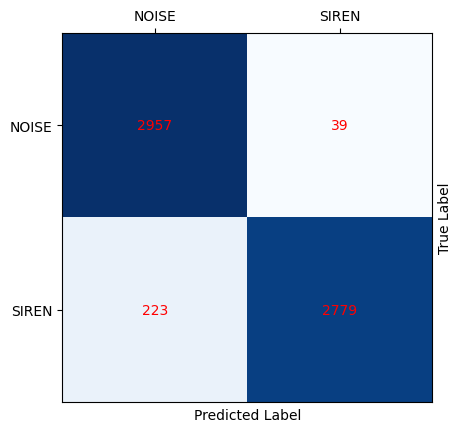

In [12]:
# LOAD THE MODEL
model.load_state_dict(torch.load(MODEL_PATH))

#Test the model with some samples from the test dataset 
model.eval()

preds = []
gts = []

for i, (images, labels) in enumerate(test_dataloader):
    images = images.to(DEVICE)
    labels = labels.to(DEVICE)

    pred = model(images.detach())
    
    for i, p in enumerate(pred):
        pred_class = round(p.squeeze().item())
        gt_class = labels[i]

        #if pred_class == 0 and gt_class == 0: print(f"CORRECT (Predicted NOISE with probability { 1 - p.squeeze() })")
        #elif pred_class == 0 and gt_class == 1: print(f"INCORRECT (Predicted NOISE with probability { 1 - p.squeeze() })")
        #elif pred_class == 1 and gt_class == 1: print(f"CORRECT (Predicted SIREN with probability { p.squeeze() })")
        #elif pred_class == 1 and gt_class == 0: print(f"INCORRECT (Predicted SIREN with probability { p.squeeze() })")

        preds.append(pred_class)
        gts.append(gt_class)

cmatrix = confusion_matrix(gts, preds)

plt.imshow(cmatrix, interpolation = 'nearest', cmap = plt.cm.Blues)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
class_names = ["NOISE", "SIREN"]
plt.xticks(ticks=[0, 1], labels=class_names)
plt.yticks(ticks=[0, 1], labels=class_names)
plt.gca().xaxis.tick_top()
plt.gca().yaxis.set_label_position('right')  

for i in range(cmatrix.shape[0]):
    for j in range(cmatrix.shape[1]):
        plt.text(j, i, cmatrix[i, j], ha='center', va='center', color='red')

plt.show()
